# Linear Single Pendulum — Weak SINDy + GLS Weighting (Exact Model, Degree 1)

We consider a planar single pendulum with viscous damping. The state is

$$
y(t) = [\theta(t),\,\omega(t)]^\top,
$$

where:

- $\theta$: angle of the pendulum w.r.t. the vertical,
- $\omega$: angular velocity.

The equations of motion are

$$
\begin{aligned}
\dot \theta &= \omega,\\
\dot \omega &= -\frac{g}{L}\theta - c\,\omega,
\end{aligned}
$$

with parameters $g>0$ (gravity), $L>0$ (length), and damping $c>0$.

We choose a small **Fourier-like feature library** that contains
$\theta$, $\omega$, and $\sin\theta$. In this basis, the true model
has *exactly* the form

$$
\begin{aligned}
\dot\theta = 0&\cdot \theta + 1\cdot \omega , \\
\dot\omega = -1&\cdot \theta - c\cdot \omega ,
\end{aligned}
$$

so that we can directly measure how well weak SINDy (with different
GLS weightings) recovers these coefficients.

In this notebook:

1. Define the nonlinear pendulum dynamics and simulate clean trajectories.
2. Define a **compact custom feature library**:
   $[\theta,\;\omega,\;\sin\theta]$.
3. Introduce **heteroscedastic noise** whose variance grows with
   $|\omega(t)|$.
4. Fit three weak SINDy models on noisy data:
   - **No weighting** (standard weak SINDy),
   - **Variance-based GLS** (weights $\propto \sigma^2(t)$),
   - **Unit-weight GLS** (`weights = 1`).
5. Compute:
   - mean relative $L_1$ coefficient error vs the **true** coefficients,
   - $L_0$ support mismatch.
6. Run a **Monte Carlo** experiment over random initial conditions and
   summarize error distributions.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import pysindy as ps
from pysindy.feature_library import WeakPDELibrary, WeightedWeakPDELibrary, PolynomialLibrary, FourierLibrary, GeneralizedLibrary

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
})


## 1. Single Pendulum Dynamics and Integrator

The ODE system is
$$
y = [\theta,\omega]^\top,\quad
\dot y = f(y),
$$

integrated with an explicit RK4 scheme.

In [2]:
def pendulum_rhs(y, g=9.81, L=1.0, c=0.5):
    """
    Time derivative for a planar single pendulum with viscous damping.

    y = [theta, omega].
    """
    theta, omega = y
    dtheta = omega
    domega = -(g / L) * theta - c * omega
    return np.array([dtheta, domega])


def rk4_step(y, h):
    k1 = pendulum_rhs(y)
    k2 = pendulum_rhs(y + 0.5 * h * k1)
    k3 = pendulum_rhs(y + 0.5 * h * k2)
    k4 = pendulum_rhs(y + h * k3)
    return y + (h / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


def simulate(y0, T=10.0, dt=1e-3):
    """Integrate the single pendulum from y0 up to time T with step dt."""
    n = int(T / dt)
    Y = np.zeros((n, len(y0)))
    Y[0] = y0
    for i in range(1, n):
        Y[i] = rk4_step(Y[i - 1], dt)
    t = np.arange(n) * dt
    return t, Y


# Parameters (for true model)
g = 9.81
L = 1.0
c = 0.5


## 2. Clean Reference Trajectory

We generate a moderately nonlinear clean trajectory and visualize it.

Reference trajectory shape: (1000, 2)


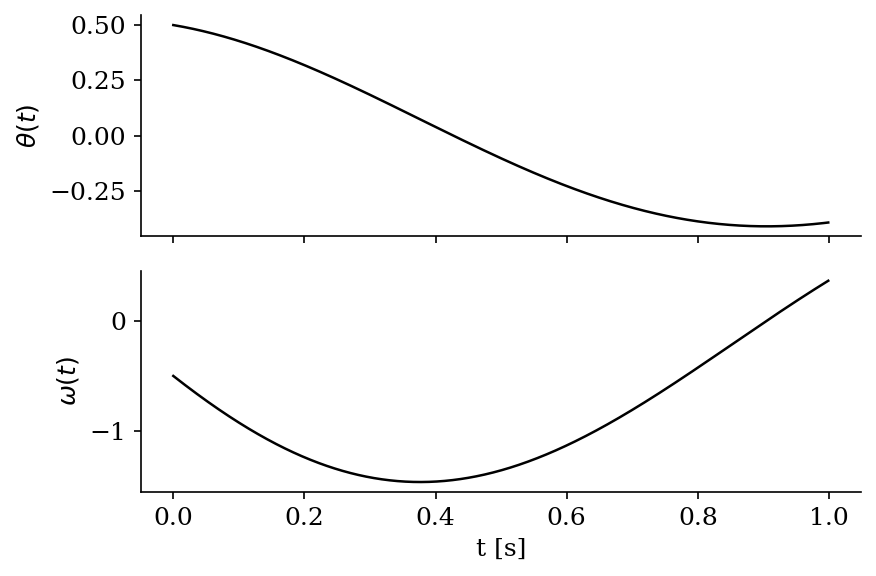

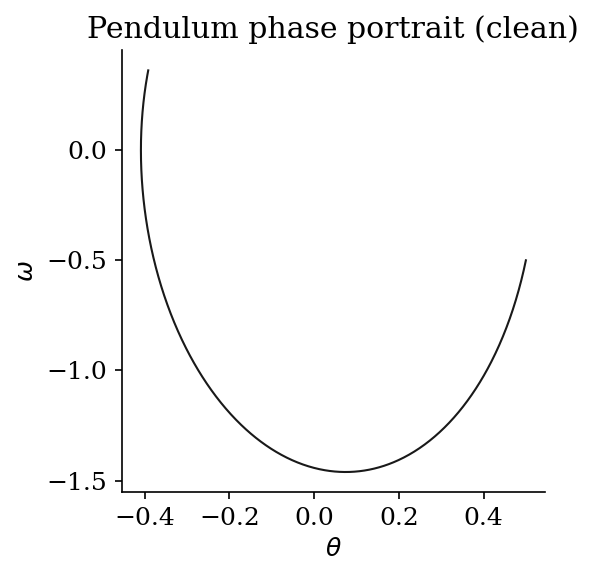

In [3]:
dt_ref = 1e-3
T_ref = 1.0

# Moderately nonlinear initial condition
y0_ref = np.array([0.5, -0.5])   # [theta0, omega0]

t_ref, Y_ref = simulate(y0_ref, T=T_ref, dt=dt_ref)
print("Reference trajectory shape:", Y_ref.shape)

# Plot reference trajectory (theta, omega)
fig, ax = plt.subplots(2, 1, figsize=(6, 4), sharex=True, dpi=150)

ax[0].plot(t_ref, Y_ref[:, 0], "k", lw=1.2)
ax[0].set_ylabel(r"$\theta(t)$")
ax[0].spines["top"].set_visible(False)
ax[0].spines["right"].set_visible(False)

ax[1].plot(t_ref, Y_ref[:, 1], "k", lw=1.2)
ax[1].set_xlabel("t [s]")
ax[1].set_ylabel(r"$\omega(t)$")
ax[1].spines["top"].set_visible(False)
ax[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# Phase portrait
fig, ax = plt.subplots(figsize=(4, 4), dpi=150)
ax.plot(Y_ref[:, 0], Y_ref[:, 1], "k", lw=1.0, alpha=0.9)
ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$\omega$")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("Pendulum phase portrait (clean)")
plt.tight_layout()
plt.show()


## 4. Heteroscedastic Noise Model for Identification

For identification experiments, we use shorter trajectories and add
**state-dependent noise**.

Let
$$
\kappa(t) = |\omega(t)|
$$
be the instantaneous angular velocity magnitude. We define the variance

$$
\sigma^2(t) = \bigl(\sigma_0 + \alpha\,\kappa(t)\bigr)^2,
$$

and noisy observations

$$
Y_{\text{noisy}}(t) = Y(t) + \varepsilon(t),\qquad
\varepsilon(t) \sim \mathcal N(0,\,\sigma^2(t) I_2).
$$

This gives a scalar variance field in time, which we feed to
`WeightedWeakPDELibrary` as `spatiotemporal_weights`.

Identification trajectory shape: (10000, 2)
Noise std range (single traj): 1e-05 to 0.075


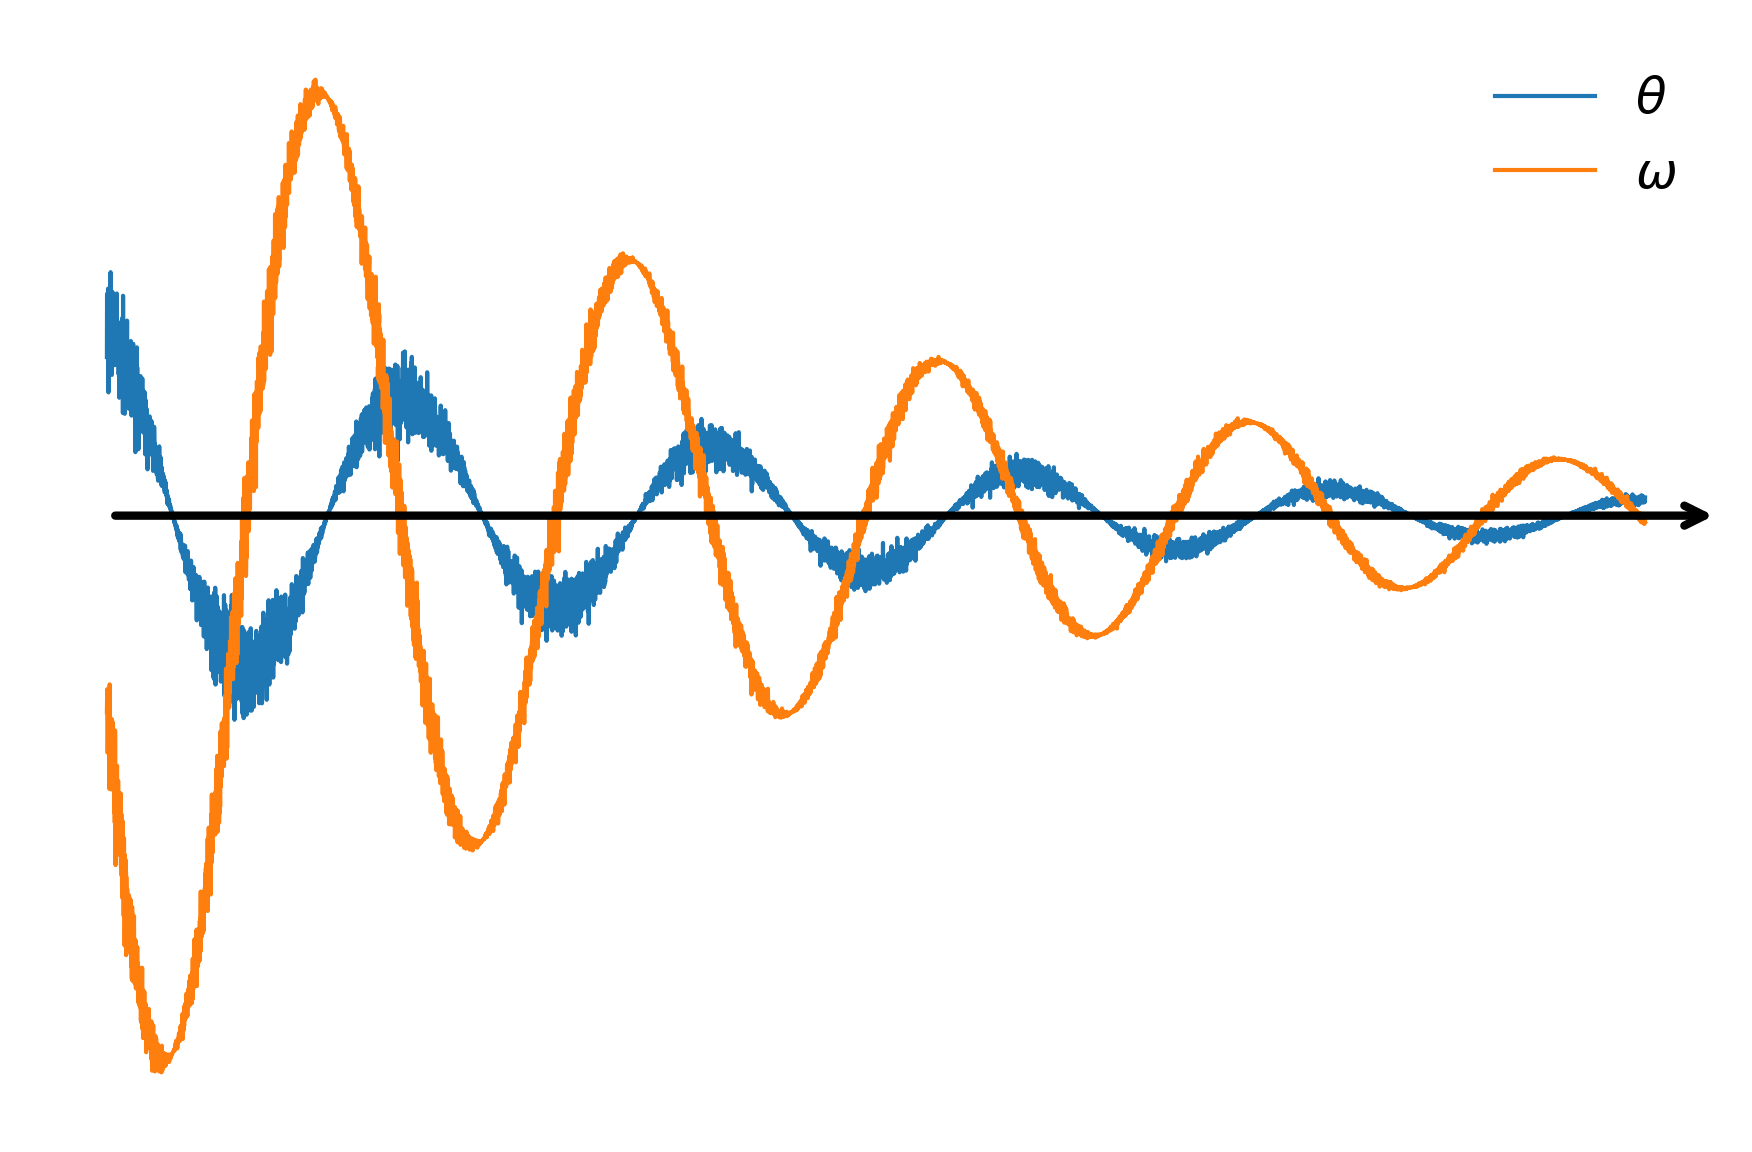

In [4]:
dt_id = 1e-3
T_id = 10.0
t_id, Y_id_clean = simulate(y0_ref, T=T_id, dt=dt_id)
print("Identification trajectory shape:", Y_id_clean.shape)

# Heteroscedastic variance based on |omega|
omega_mag = np.abs(Y_id_clean[:, 0])   # (T_id,)
sigma0 = 0
alpha_noise = 0.15

variance_id = (sigma0 + alpha_noise * omega_mag)**2  # (T_id,)
variance_id = np.maximum(variance_id, 1e-10)
std_id = np.sqrt(variance_id)

rng = np.random.default_rng(123)
noise_id = std_id[:, None] * rng.standard_normal(size=Y_id_clean.shape)
Y_id_noisy = Y_id_clean + noise_id

print("Noise std range (single traj):", std_id.min(), "to", std_id.max())

# Plot θ, ω with x-axis moved to the middle and ticks removed + arrow
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

ax.plot(t_id, Y_id_noisy[:, 0], lw=1.0, label=r"$\theta$")
ax.plot(t_id, Y_id_noisy[:, 1], lw=1.0, label=r"$\omega$")

# Move x-axis to the middle (y = 0)
ax.spines['bottom'].set_position(('data', 0))

# Hide unused spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# Remove ticks entirely
ax.set_xticks([])
ax.set_yticks([])

# Optional: remove axis labels
# ax.set_xlabel("")
# ax.set_ylabel("")

# Add arrow indicating positive time direction
# Arrow slightly below the axis (adjust 'dy' if needed)
arrow_y = 0  # y-position of the time axis
ax.annotate(
    "", 
    xy=(t_id[-1]+0.5, arrow_y), 
    xytext=(t_id[0], arrow_y),
    arrowprops=dict(arrowstyle="->", lw=2.0, color="black"),
)

# Optional legend
ax.legend(frameon=False)

# Grid only on y-direction (but hidden due to no ticks)
ax.grid(axis="y", linestyle=":", linewidth=0.5, alpha=0.6)

plt.tight_layout()
plt.show()


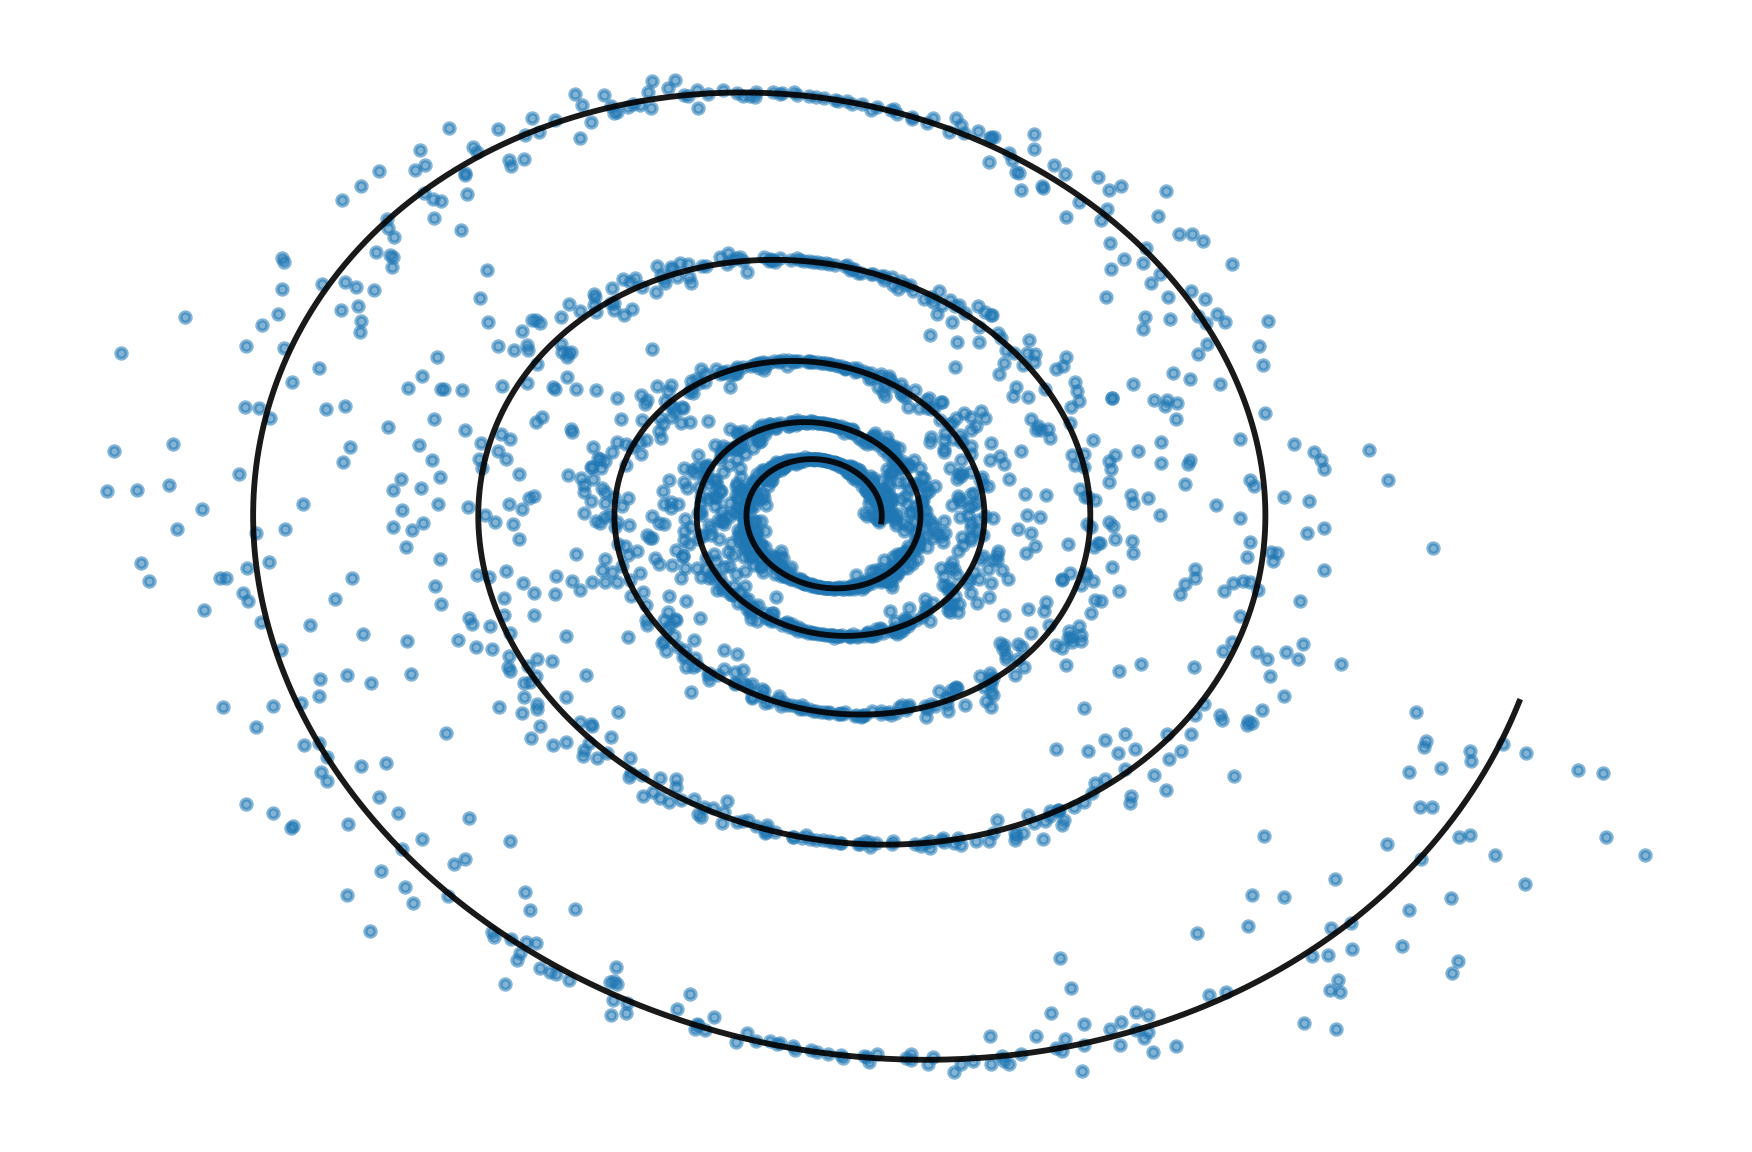

In [5]:
# Phase-space plot: clean (black line) vs noisy (blue scatter)

fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

theta_clean = Y_id_clean[:, 0]
omega_clean = Y_id_clean[:, 1]

theta_noisy = Y_id_noisy[:, 0]
omega_noisy = Y_id_noisy[:, 1]

# Subsample noisy points to avoid clutter
step = max(1, len(theta_noisy) // 2000)

# Clean trajectory (line)
ax.plot(theta_clean, omega_clean,
        color="black", lw=1.4, alpha=0.9)

# Noisy trajectory (scatter)
ax.scatter(theta_noisy[::step], omega_noisy[::step],
           color="#1f77b4", s=6, alpha=0.55)

# Equal aspect ratio
# ax.set_aspect("equal", adjustable="box")

# Remove all ticks and spines for minimalist look
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

# Optional label for clarity (can remove if needed)
# ax.set_xlabel(r"$\theta$")
# ax.set_ylabel(r"$\omega$")

plt.tight_layout()
plt.show()


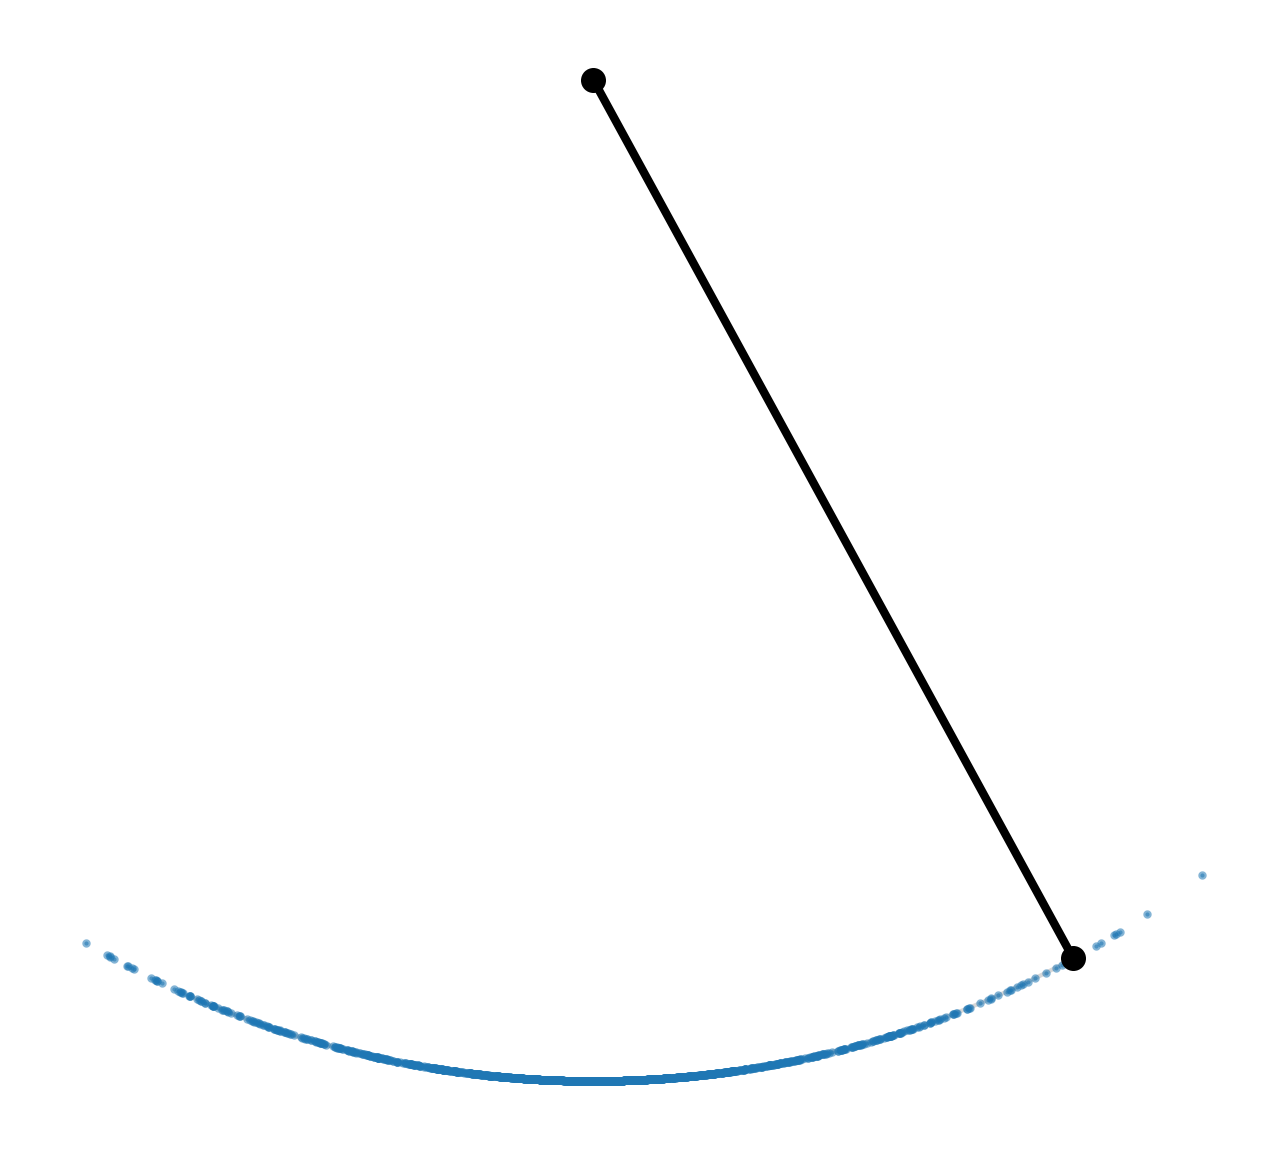

In [6]:
# ============================================================
# Figure — Single pendulum in Cartesian coordinates
# ============================================================

# If not already defined:
L = 1.0  # pendulum length

theta_clean = Y_id_clean[:, 0]
theta_noisy = Y_id_noisy[:, 0]

# Clean trajectory in Cartesian coordinates
x_clean = L * np.sin(theta_clean)
y_clean = -L * np.cos(theta_clean)

# Noisy trajectory
x_noisy = L * np.sin(theta_noisy)
y_noisy = -L * np.cos(theta_noisy)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
})

fig, ax = plt.subplots(figsize=(6.0, 4.0), dpi=300)

# --- Clean tip trajectory (background) ---
ax.plot(
    x_clean, y_clean,
    color="lightgray",
    lw=1.0,
    alpha=0.9,
    zorder=1,
)

# --- Noisy tip positions (sparse subsampling for aesthetics) ---
step = max(len(x_noisy) // 1500, 1)  # avoid overplotting
ax.scatter(
    x_noisy[::step], y_noisy[::step],
    marker=".", s=4,
    alpha=0.55,
    zorder=2,
)

# --- Draw the pendulum at initial condition (t = 0) ---
x0 = x_clean[0]
y0 = y_clean[0]

# Rod
ax.plot(
    [0.0, x0], [0.0, y0],
    color="black",
    lw=2.0,
    zorder=3,
)

# Pivot + bob
ax.scatter(
    [0.0], [0.0],
    color="black",
    s=25,
    zorder=4,
)
ax.scatter(
    [x0], [y0],
    color="black",
    s=25,
    zorder=4,
)

# --- Aesthetics ---
ax.set_aspect("equal")
# ax.set_xlim(1.1 * np.min(x_clean), 1.1 * np.max(x_clean))
# ax.set_ylim(1.1 * np.min(y_clean), 1.1 * np.max(y_clean))

ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

# Optional title (comment out if not needed)
# ax.set_title("Single pendulum tip trajectory")

plt.tight_layout()
plt.show()


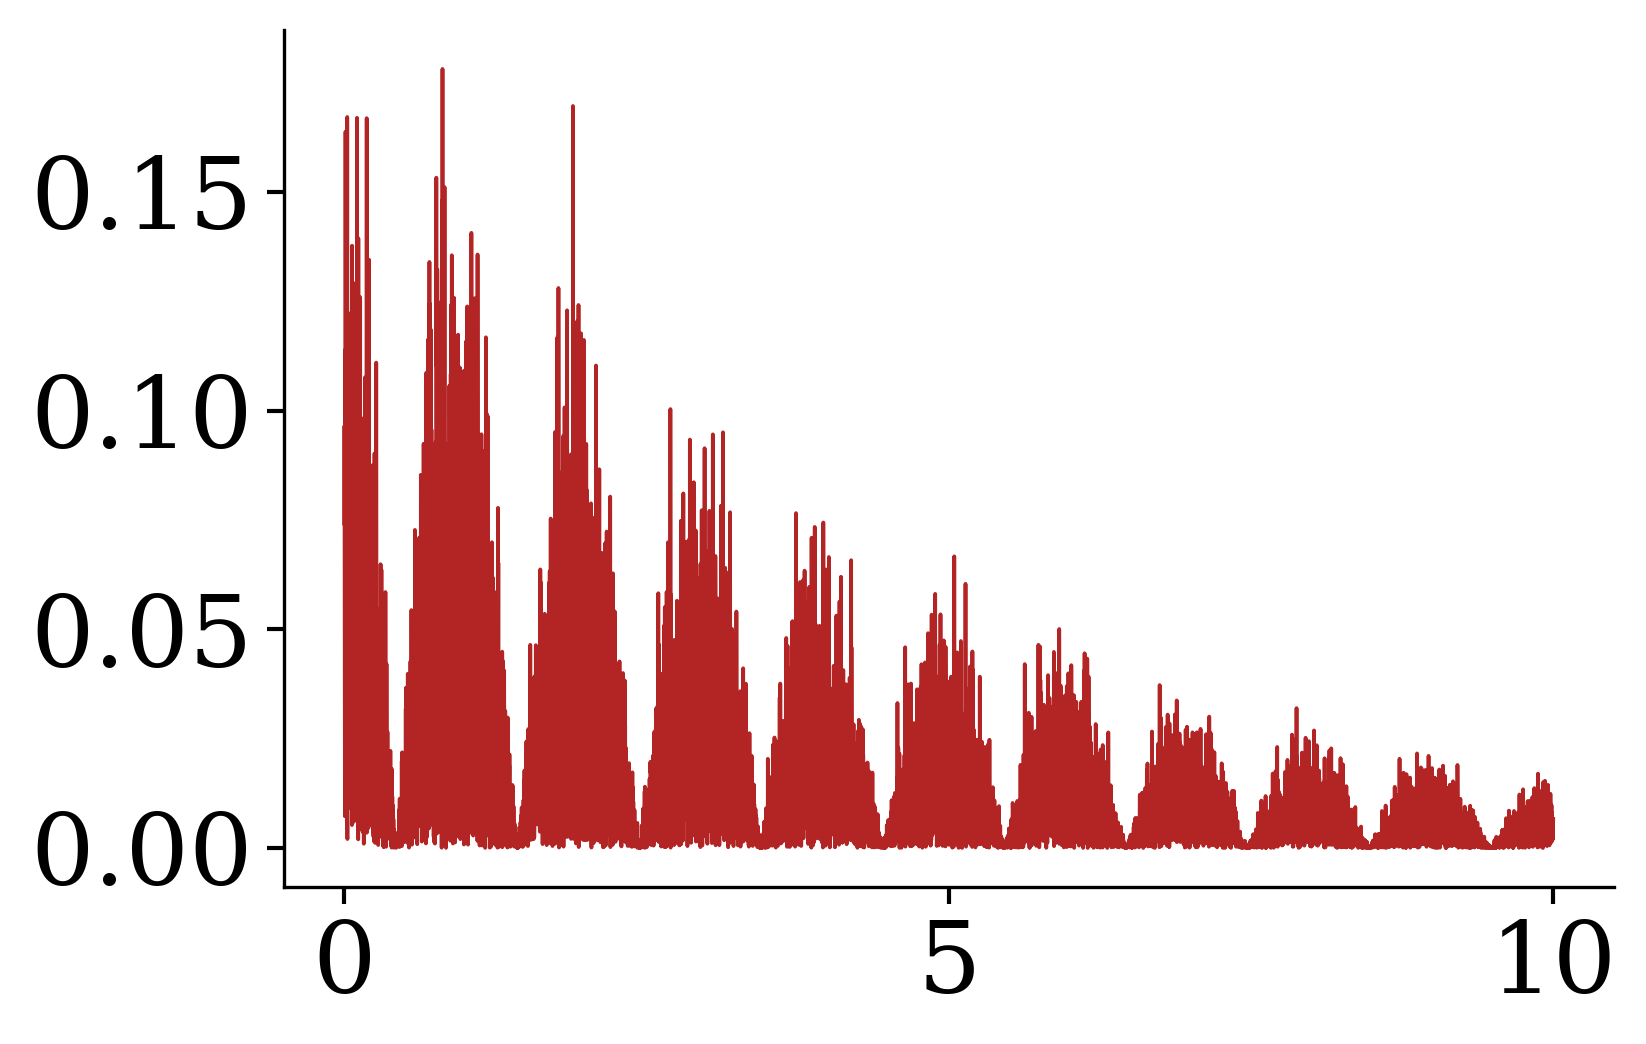

In [7]:
# ------------------------------------------------------------
# Residual plot for theta: ||ε(t)|| = |θ_noisy(t) - θ_clean(t)|
# ------------------------------------------------------------
theta_clean = Y_id_clean[:, 0]
theta_noisy = Y_id_noisy[:, 0]

eps_theta = np.abs(theta_noisy - theta_clean)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 24,
})

# Dark brownish red (close to the reference figure)

steelred = "#b32425"

fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

ax.plot(
    t_id,
    eps_theta,
    lw=0.9,
    color=steelred,
)

# ax.set_xlabel(r"$t\,[\mathrm{s}]$")
# ax.set_ylabel(r"$\|\varepsilon(t)\|$")
# ax.set_xlim(t_id[0], t_id[-1])
# ax.set_ylim(0, 1.05 * np.max(eps_theta))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", width=1.0, length=4)
ax.grid(False)

plt.tight_layout()
plt.show()


## 5. Weak SINDy with Temporal Weighting (Single Trajectory)

We now construct three weak libraries for the *noisy* identification
trajectory:

- **No weighting**: standard weak SINDy.
- **Variance GLS**: temporal weights equal to the variance field
  $\sigma^2(t)$.
- **Unit GLS**: temporal weights are identically one.

Each model is fit with an **ensemble optimizer** and we compare each
ensemble member against the **true coefficients** in our
\([\theta,\omega,\sin\theta]\) basis.

Errors:

- **Relative \(L_1\) error** on nonzero entries of $\Xi_{\text{true}}$,
- **\(L_0\) support error**: number of indices where the algebraic support
  differs between estimate and truth.

In [8]:
feature_library = ps.PolynomialLibrary(degree=1, include_bias=False)
# True coefficients in this basis:
true_coef = np.array([
    [0.0,      1.0],     # theta_dot
    [-g / L,   -c],     # omega_dot
])  # shape (2, 6)

C_true_flat = true_coef.reshape(-1)
print("true_coef shape:", true_coef.shape)


true_coef shape: (2, 2)


In [9]:
def coeff_errors(C_est, C_true, tol_support=1e-6, tol_rel=1e-8):
    """
    Relative L1 error + L0 support mismatch.

    C_est, C_true : 1D arrays.
    """
    C_est = np.asarray(C_est).ravel()
    C_true = np.asarray(C_true).ravel()

    # L0 support mismatch
    supp_true = np.abs(C_true) > tol_support
    supp_est  = np.abs(C_est)  > tol_support
    l0_err = np.count_nonzero(supp_true ^ supp_est)

    # Relative L1 on nonzero true coefficients
    if np.any(supp_true):
        C_true_nz = C_true[supp_true]
        C_est_nz  = C_est[supp_true]
        denom = np.maximum(np.abs(C_true_nz), tol_rel)
        rel_err = np.abs(C_est_nz - C_true_nz) / denom
        l1_rel = np.mean(rel_err)
    else:
        l1_rel = 0.0

    return l1_rel, l0_err


In [10]:
# %%
# Weak and weighted weak libraries for the identification trajectory
XT_id = t_id[:, None]

np.random.seed(0)
weak_lib = WeakPDELibrary(
    function_library=feature_library,
    derivative_order=1,
    spatiotemporal_grid=XT_id,
    is_uniform=True,
    include_bias=False,
    H_xt = 0.1,
    K=500
)

np.random.seed(0)
weighted_weak_lib_var = WeightedWeakPDELibrary(
    function_library=feature_library,
    derivative_order=1,
    spatiotemporal_grid=XT_id,
    spatiotemporal_weights=variance_id,  # (T_id,)
    is_uniform=True,
    include_bias=False,
    H_xt = 0.1,
    K=500,
)

np.random.seed(0)
weighted_weak_lib_ones = WeightedWeakPDELibrary(
    function_library=feature_library,
    derivative_order=1,
    spatiotemporal_grid=XT_id,
    spatiotemporal_weights=np.ones_like(variance_id),
    is_uniform=True,
    include_bias=False,
    H_xt = 0.1,
    K=500
)


In [11]:
# Ensemble optimizers
opt_std = ps.EnsembleOptimizer(ps.STLSQ(threshold=0.01),
                               bagging=True, n_models=100)
opt_var = ps.EnsembleOptimizer(ps.STLSQ(threshold=0.01),
                               bagging=True, n_models=100)
opt_ones = ps.EnsembleOptimizer(ps.STLSQ(threshold=0.01),
                                bagging=True, n_models=100)

model = ps.SINDy(feature_library=feature_library, optimizer=ps.STLSQ(threshold=0.01))
model_std = ps.SINDy(feature_library=weak_lib, optimizer=opt_std)
model_var = ps.SINDy(feature_library=weighted_weak_lib_var, optimizer=opt_var)
model_ones = ps.SINDy(feature_library=weighted_weak_lib_ones, optimizer=opt_ones)

model.fit(Y_id_clean,t_id)
model_std.fit(Y_id_noisy, t=t_id)
model_var.fit(Y_id_noisy, t=t_id)
model_ones.fit(Y_id_noisy, t=t_id)

model.print()
print("\n===== Weak SINDy (no weighting) =====")
model_std.print()
print("\n===== Weighted Weak SINDy (variance GLS) =====")
model_var.print()
print("\n===== Weighted Weak SINDy (weights = 1 GLS) =====")
model_ones.print()


(x0)' = 1.000 x1
(x1)' = -9.810 x0 + -0.500 x1

===== Weak SINDy (no weighting) =====
(x0)' = -0.015 x0 + 0.997 x1
(x1)' = -9.824 x0 + -0.509 x1

===== Weighted Weak SINDy (variance GLS) =====
(x0)' = 1.002 x1
(x1)' = -9.814 x0 + -0.505 x1

===== Weighted Weak SINDy (weights = 1 GLS) =====
(x0)' = 1.001 x1
(x1)' = -9.816 x0 + -0.506 x1


In [12]:
print(C_true_flat)


[ 0.    1.   -9.81 -0.5 ]


In [13]:
model_ones.optimizer.coef_.reshape(-1)


array([ 0.        ,  1.00125789, -9.81575854, -0.50649645])

In [14]:
# Stack ensemble coefficients: (E, 2, n_terms)
coef_std  = np.stack(opt_std.coef_list,  axis=0)
coef_var  = np.stack(opt_var.coef_list,  axis=0)
coef_ones = np.stack(opt_ones.coef_list, axis=0)

print("coef_std shape:  ", coef_std.shape)
print("coef_var shape:  ", coef_var.shape)
print("coef_ones shape: ", coef_ones.shape)

E, n_states, n_terms = coef_std.shape

rel_L1_std, rel_L1_var, rel_L1_ones = [], [], []
L0_std, L0_var, L0_ones = [], [], []

for e in range(E):
    C_std_e  = coef_std[e].reshape(-1)
    C_var_e  = coef_var[e].reshape(-1)
    C_ones_e = coef_ones[e].reshape(-1)

    l1_s, l0_s = coeff_errors(C_std_e,  C_true_flat)
    l1_v, l0_v = coeff_errors(C_var_e,  C_true_flat)
    l1_o, l0_o = coeff_errors(C_ones_e, C_true_flat)

    rel_L1_std.append(l1_s);   L0_std.append(l0_s)
    rel_L1_var.append(l1_v);   L0_var.append(l0_v)
    rel_L1_ones.append(l1_o);  L0_ones.append(l0_o)

rel_L1_std  = np.asarray(rel_L1_std)
rel_L1_var  = np.asarray(rel_L1_var)
rel_L1_ones = np.asarray(rel_L1_ones)

L0_std  = np.asarray(L0_std,  dtype=int)
L0_var  = np.asarray(L0_var,  dtype=int)
L0_ones = np.asarray(L0_ones, dtype=int)

print("\nSingle-trajectory ensemble results:")
print("  Mean relative L1 (no weighting):   ", np.mean(rel_L1_std))
print("  Mean relative L1 (variance GLS):   ", np.mean(rel_L1_var))
print("  Mean relative L1 (weights=1 GLS):  ", np.mean(rel_L1_ones))
print("  Mean L0 (no weighting):            ", np.mean(L0_std))
print("  Mean L0 (variance GLS):            ", np.mean(L0_var))
print("  Mean L0 (weights=1 GLS):           ", np.mean(L0_ones))


coef_std shape:   (100, 2, 2)
coef_var shape:   (100, 2, 2)
coef_ones shape:  (100, 2, 2)

Single-trajectory ensemble results:
  Mean relative L1 (no weighting):    0.009038102572004325
  Mean relative L1 (variance GLS):    0.004077474955707974
  Mean relative L1 (weights=1 GLS):   0.0051268926318540605
  Mean L0 (no weighting):             0.77
  Mean L0 (variance GLS):             0.0
  Mean L0 (weights=1 GLS):            0.23


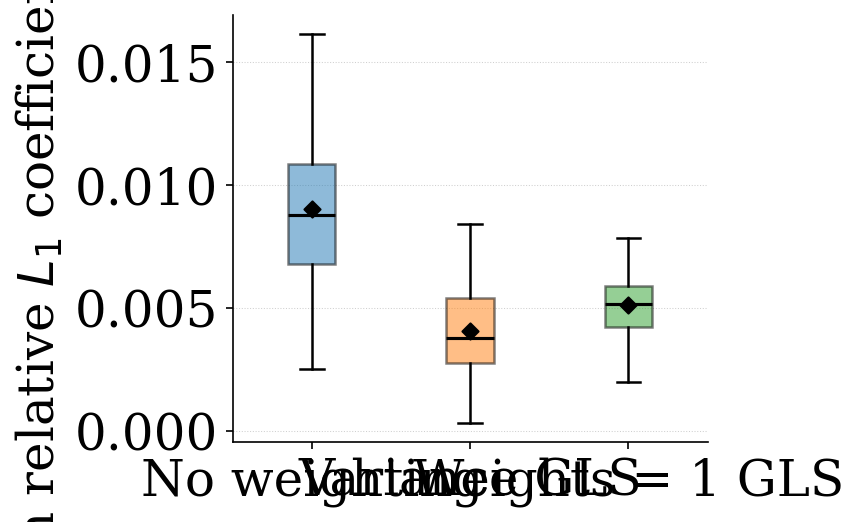

In [15]:
# Boxplot: relative L1 errors (single trajectory)
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)

data = [rel_L1_std, rel_L1_var, rel_L1_ones]
labels = ["No weighting", "Variance GLS", "Weights = 1 GLS"]
means = [np.mean(d) for d in data]

bp = ax.boxplot(
    data,
    labels=labels,
    showfliers=False,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=1.5),
    boxprops=dict(linewidth=1.2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
)

colors = ["tab:blue", "tab:orange", "tab:green"]
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.5)

for x, m in zip([1, 2, 3], means):
    ax.scatter(x, m, marker="D", color="black", s=30, zorder=3)

ax.set_ylabel(r"Mean relative $L_1$ coefficient error")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle=":", linewidth=0.5, alpha=0.6)
plt.tight_layout()
plt.show()


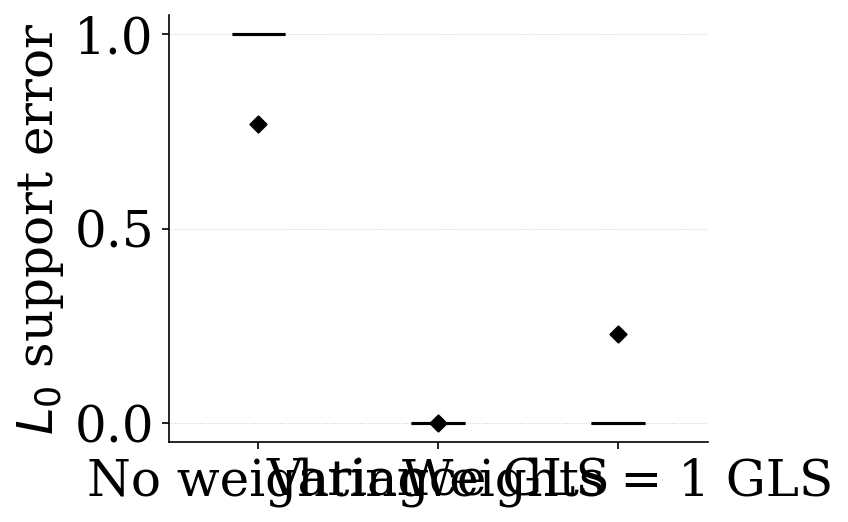

In [16]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)

data_L0 = [L0_std, L0_var, L0_ones]
labels_L0 = ["No weighting", "Variance GLS", "Weights = 1 GLS"]
means_L0 = [np.mean(d) for d in data_L0]

bp = ax.boxplot(
    data_L0,
    labels=labels_L0,
    showfliers=False,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=1.5),
    boxprops=dict(linewidth=1.2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
)

colors_L0 = ["tab:blue", "tab:orange", "tab:green"]
for patch, c in zip(bp["boxes"], colors_L0):
    patch.set_facecolor(c)
    patch.set_alpha(0.5)

for x, m in zip([1, 2, 3], means_L0):
    ax.scatter(x, m, marker="D", color="black", s=30, zorder=3)

ax.set_ylabel(r"$L_0$ support error")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle=":", linewidth=0.5, alpha=0.6)
plt.tight_layout()
plt.show()


## 6. Monte Carlo Robustness Experiment

Finally, we assess robustness across **multiple initial conditions**.
For each run:

1. Sample a random initial condition
   $$
   y_0 = (\theta_0,\omega_0),\quad
   \theta_0 \sim \mathcal U([-a,a]),\; \omega_0 \sim \mathcal U([-b,b]).
   $$
2. Simulate a clean trajectory of length \(T_{\text{mc}} = 5\) s.
3. Build a heteroscedastic variance field from \(|\omega(t)|\) and
   add noise with the same model as above.
4. Fit the three weak libraries with smaller ensembles and
   **average coefficients over ensemble members**.
5. Compute per-run relative \(L_1\) and \(L_0\) errors vs the **true**
   coefficients.

We then summarize the error distributions across runs.

In [17]:
## 6. Monte Carlo Robustness Experiment

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
})


def make_optimizer(threshold=0.04):
    return ps.EnsembleOptimizer(
        ps.STLSQ(threshold=threshold),
        bagging=True,
    )

# --------------------------------------------------------------------
# 6.1 Monte Carlo: per-run accuracy and sparsity at full trajectory
# --------------------------------------------------------------------
N_IC = 100      # number of different initial conditions
T_mc = 10.0
dt_mc = 1e-3
K     = 500
H_xt  = 0.1

theta_bounds = np.array([-1.0,  1.0])
omega_bounds = np.array([-0.25, 0.25])

rng_ic    = np.random.default_rng(999)
rng_noise = np.random.default_rng(1234)

rel_L1_std_runs,  rel_L1_var_runs,  rel_L1_ones_runs  = [], [], []
L0_std_runs,      L0_var_runs,      L0_ones_runs      = [], [], []

for i in tqdm(range(N_IC)):

    # 1) random initial condition
    theta0 = rng_ic.uniform(*theta_bounds)
    omega0 = rng_ic.uniform(*omega_bounds)
    y0_run = np.array([theta0, omega0])

    # 2) clean trajectory
    t_run, Y_run_clean = simulate(y0_run, T=T_mc, dt=dt_mc)

    # 3) heteroscedastic noise model based on |omega|
    omega_mag_run = np.abs(Y_run_clean[:, 0])  # column 1 = omega
    variance_run  = (sigma0 + alpha_noise * omega_mag_run) ** 2
    variance_run  = np.maximum(variance_run, 1e-10)
    std_run       = np.sqrt(variance_run)

    XT_run       = t_run[:, None]
    base_lib_run = feature_library

    # 4) weak libraries with shared random test functions
    tf_seed = 10_000 + i

    np.random.seed(tf_seed)
    weak_lib_run = WeakPDELibrary(
        function_library=base_lib_run,
        derivative_order=1,
        spatiotemporal_grid=XT_run,
        is_uniform=True,
        include_bias=False,
        K=K,
        H_xt=H_xt,
    )

    np.random.seed(tf_seed)
    weighted_weak_lib_var_run = WeightedWeakPDELibrary(
        function_library=base_lib_run,
        derivative_order=1,
        spatiotemporal_grid=XT_run,
        spatiotemporal_weights=variance_run,
        is_uniform=True,
        include_bias=False,
        K=K,
        H_xt=H_xt,
    )

    np.random.seed(tf_seed)
    weighted_weak_lib_ones_run = WeightedWeakPDELibrary(
        function_library=base_lib_run,
        derivative_order=1,
        spatiotemporal_grid=XT_run,
        spatiotemporal_weights=np.ones_like(variance_run),
        is_uniform=True,
        include_bias=False,
        K=K,
        H_xt=H_xt,
    )

    libraries = {
        "std":  weak_lib_run,
        "var":  weighted_weak_lib_var_run,
        "ones": weighted_weak_lib_ones_run,
    }

    optimizers = {key: make_optimizer() for key in libraries}
    models = {
        key: ps.SINDy(feature_library=libraries[key], optimizer=optimizers[key])
        for key in libraries
    }

    # 5) single noise realization for this IC
    noise_run   = std_run[:, None] * rng_noise.standard_normal(size=Y_run_clean.shape)
    Y_run_noisy = Y_run_clean + noise_run

    for m in models.values():
        m.fit(Y_run_noisy, t=t_run)

    # ensemble-averaged coefficients (per IC)
    C_std_run  = np.mean(np.stack(optimizers["std"].coef_list,  axis=0), axis=0).reshape(-1)
    C_var_run  = np.mean(np.stack(optimizers["var"].coef_list,  axis=0), axis=0).reshape(-1)
    C_ones_run = np.mean(np.stack(optimizers["ones"].coef_list, axis=0), axis=0).reshape(-1)

    l1_s, l0_s = coeff_errors(C_std_run,  C_true_flat)
    l1_v, l0_v = coeff_errors(C_var_run,  C_true_flat)
    l1_o, l0_o = coeff_errors(C_ones_run, C_true_flat)

    rel_L1_std_runs.append(l1_s);   L0_std_runs.append(l0_s)
    rel_L1_var_runs.append(l1_v);   L0_var_runs.append(l0_v)
    rel_L1_ones_runs.append(l1_o);  L0_ones_runs.append(l0_o)

rel_L1_std_runs  = np.asarray(rel_L1_std_runs)
rel_L1_var_runs  = np.asarray(rel_L1_var_runs)
rel_L1_ones_runs = np.asarray(rel_L1_ones_runs)

L0_std_runs  = np.asarray(L0_std_runs,  dtype=int)
L0_var_runs  = np.asarray(L0_var_runs,  dtype=int)
L0_ones_runs = np.asarray(L0_ones_runs, dtype=int)

print("\nMonte Carlo (per-run ensemble-averaged coefficients):")
print("  Mean relative L1 (no weighting):   ", np.mean(rel_L1_std_runs))
print("  Mean relative L1 (variance GLS):   ", np.mean(rel_L1_var_runs))
print("  Mean relative L1 (weights=1 GLS):  ", np.mean(rel_L1_ones_runs))
print("  Mean L0 (no weighting):            ", np.mean(L0_std_runs))
print("  Mean L0 (variance GLS):            ", np.mean(L0_var_runs))
print("  Mean L0 (weights=1 GLS):           ", np.mean(L0_ones_runs))



100%|██████████| 100/100 [01:23<00:00,  1.20it/s]


Monte Carlo (per-run ensemble-averaged coefficients):
  Mean relative L1 (no weighting):    0.04051513776397341
  Mean relative L1 (variance GLS):    0.002982687394116061
  Mean relative L1 (weights=1 GLS):   0.0052922556058933356
  Mean L0 (no weighting):             0.73
  Mean L0 (variance GLS):             0.0
  Mean L0 (weights=1 GLS):            0.02


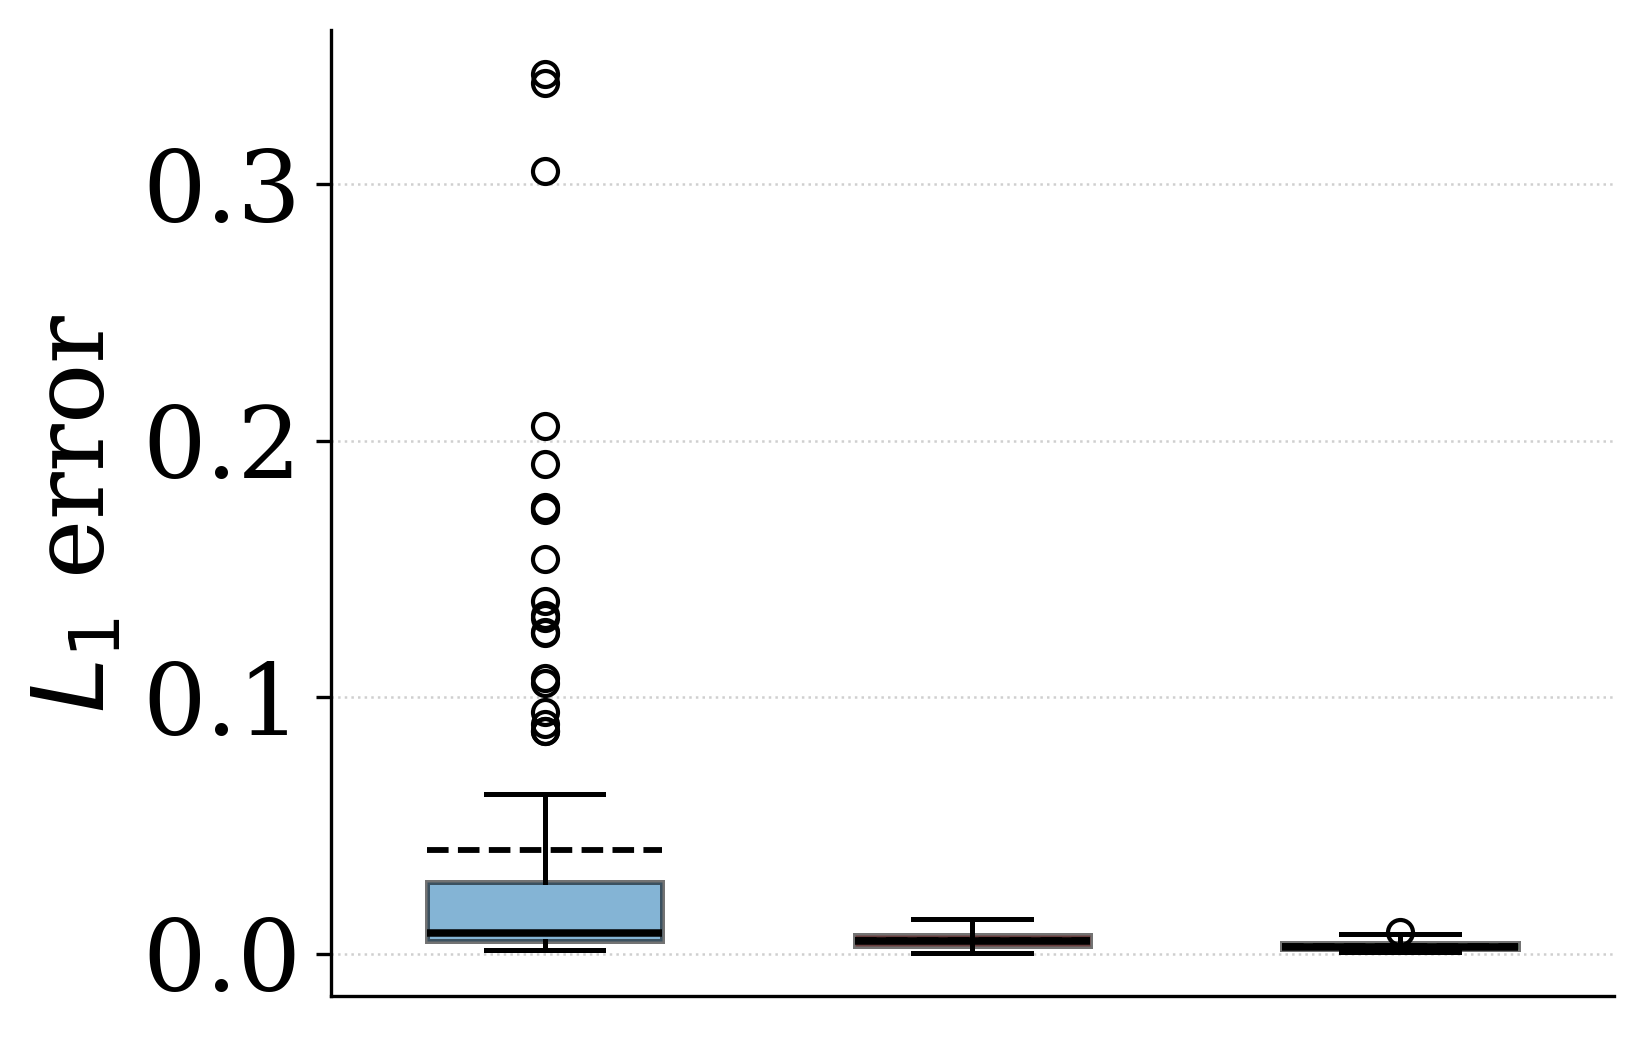

In [18]:
# --------------------------------------------------------------------
# Publication-quality Plot 1: Accuracy (relative L1)
# --------------------------------------------------------------------

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 24,
})

rel_L1_all = [rel_L1_std_runs, rel_L1_ones_runs, rel_L1_var_runs]

# Distinct but muted publication colors
colors = ["#1f77b4", "#d62728", "#2ca02c"]  # blue, red, green

fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

bp = ax.boxplot(
    rel_L1_all,
    showmeans=True,
    meanline=True,
    widths=0.55,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=1.8),
    meanprops=dict(color="black", linewidth=1.4),
    boxprops=dict(linewidth=1.2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
)

# Color each box
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.55)

# Remove x-axis ticks and labels (you add legend externally)
ax.set_xticks([])

ax.set_ylabel(r"$L_1$ error")

# Aesthetics
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle=":", linewidth=0.6, alpha=0.6)

plt.tight_layout()
plt.show()


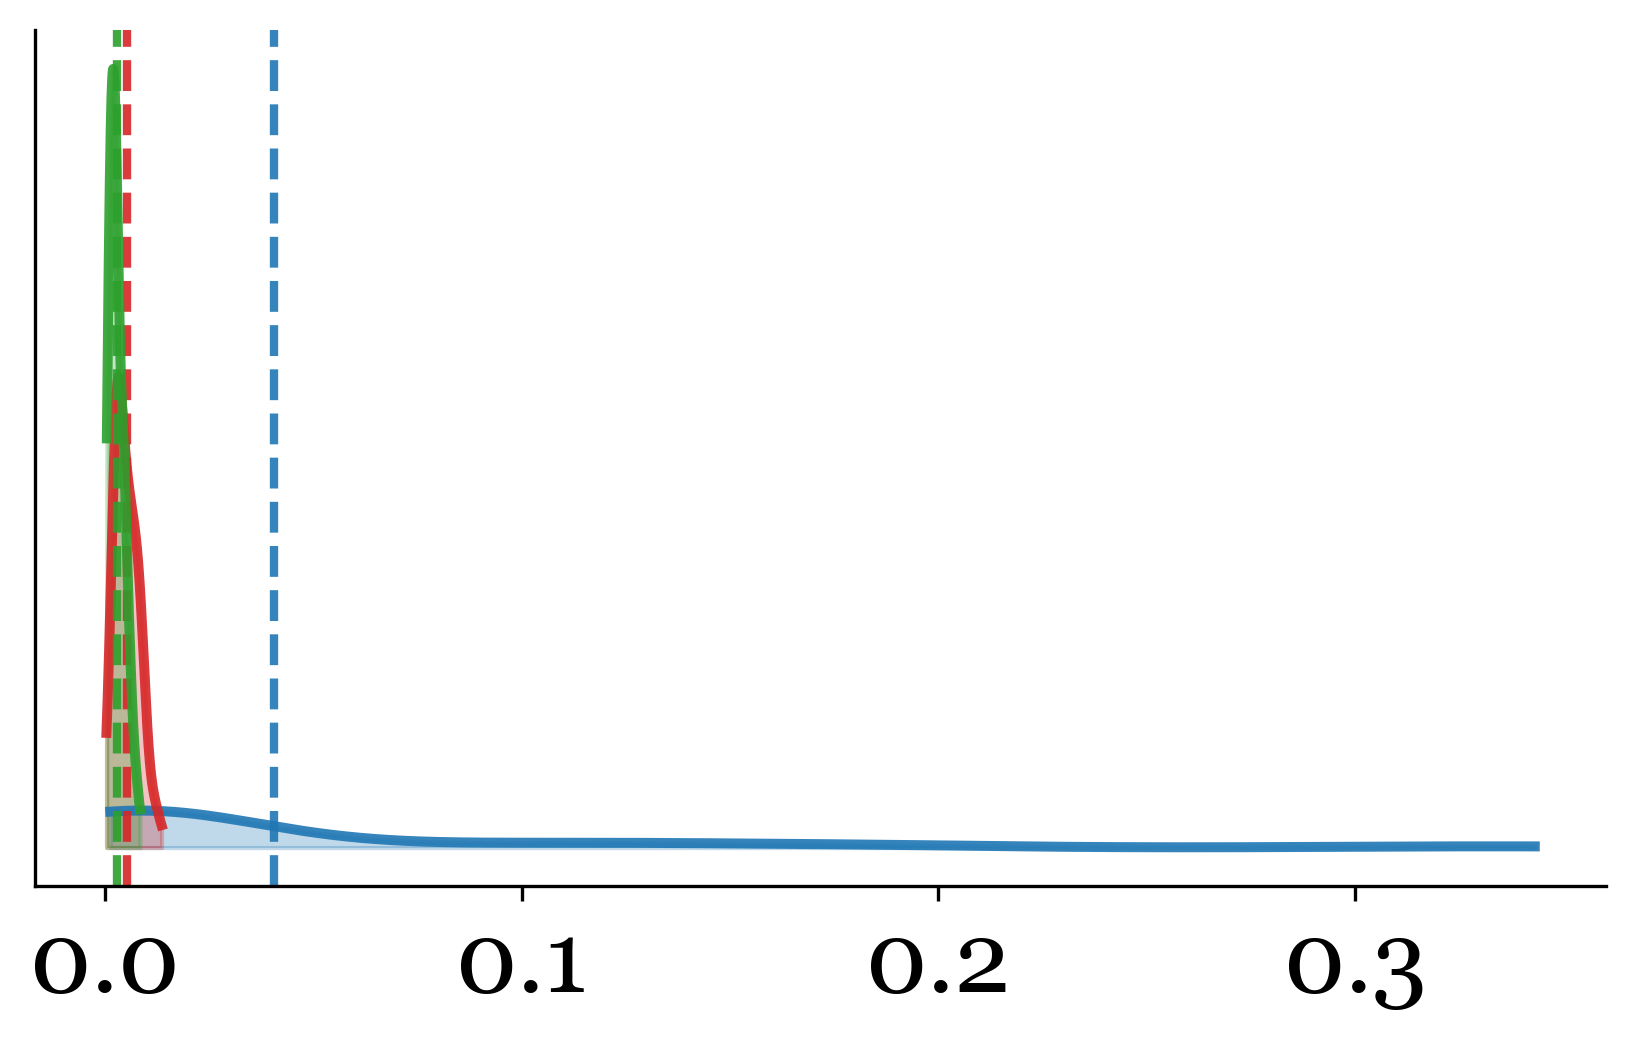

In [19]:
from scipy.stats import gaussian_kde

# --------------------------------------------------------------------
# Publication-quality Density Plot: Accuracy (relative L1)
# --------------------------------------------------------------------

plt.rcParams.update({
    "font.family": "Georgia",
    "font.size": 24,
})

rel_L1_all = [
    rel_L1_std_runs,
    rel_L1_ones_runs,
    rel_L1_var_runs
]

colors = ["#1f77b4", "#d62728", "#2ca02c"]  # blue, red, green

fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

# KDE curves + mean lines
for data, color in zip(rel_L1_all, colors):

    # KDE
    kde = gaussian_kde(data)
    x_eval = np.linspace(min(data), max(data), 400)
    y_eval = kde(x_eval)

    ax.plot(x_eval, y_eval, color=color, lw=2.4, alpha=0.9)
    ax.fill_between(x_eval, y_eval, alpha=0.28, color=color)

    # Mean vertical line
    mean_val = np.mean(data)
    ax.axvline(mean_val, linestyle="--", color=color, lw=2.0, alpha=0.9)

# No x-ticks (legend added externally)
ax.set_yticks([])

# ax.set_ylabel(r"$L_1$ error")

# Aesthetics
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle=":", linewidth=0.6, alpha=0.6)

plt.tight_layout()
plt.show()


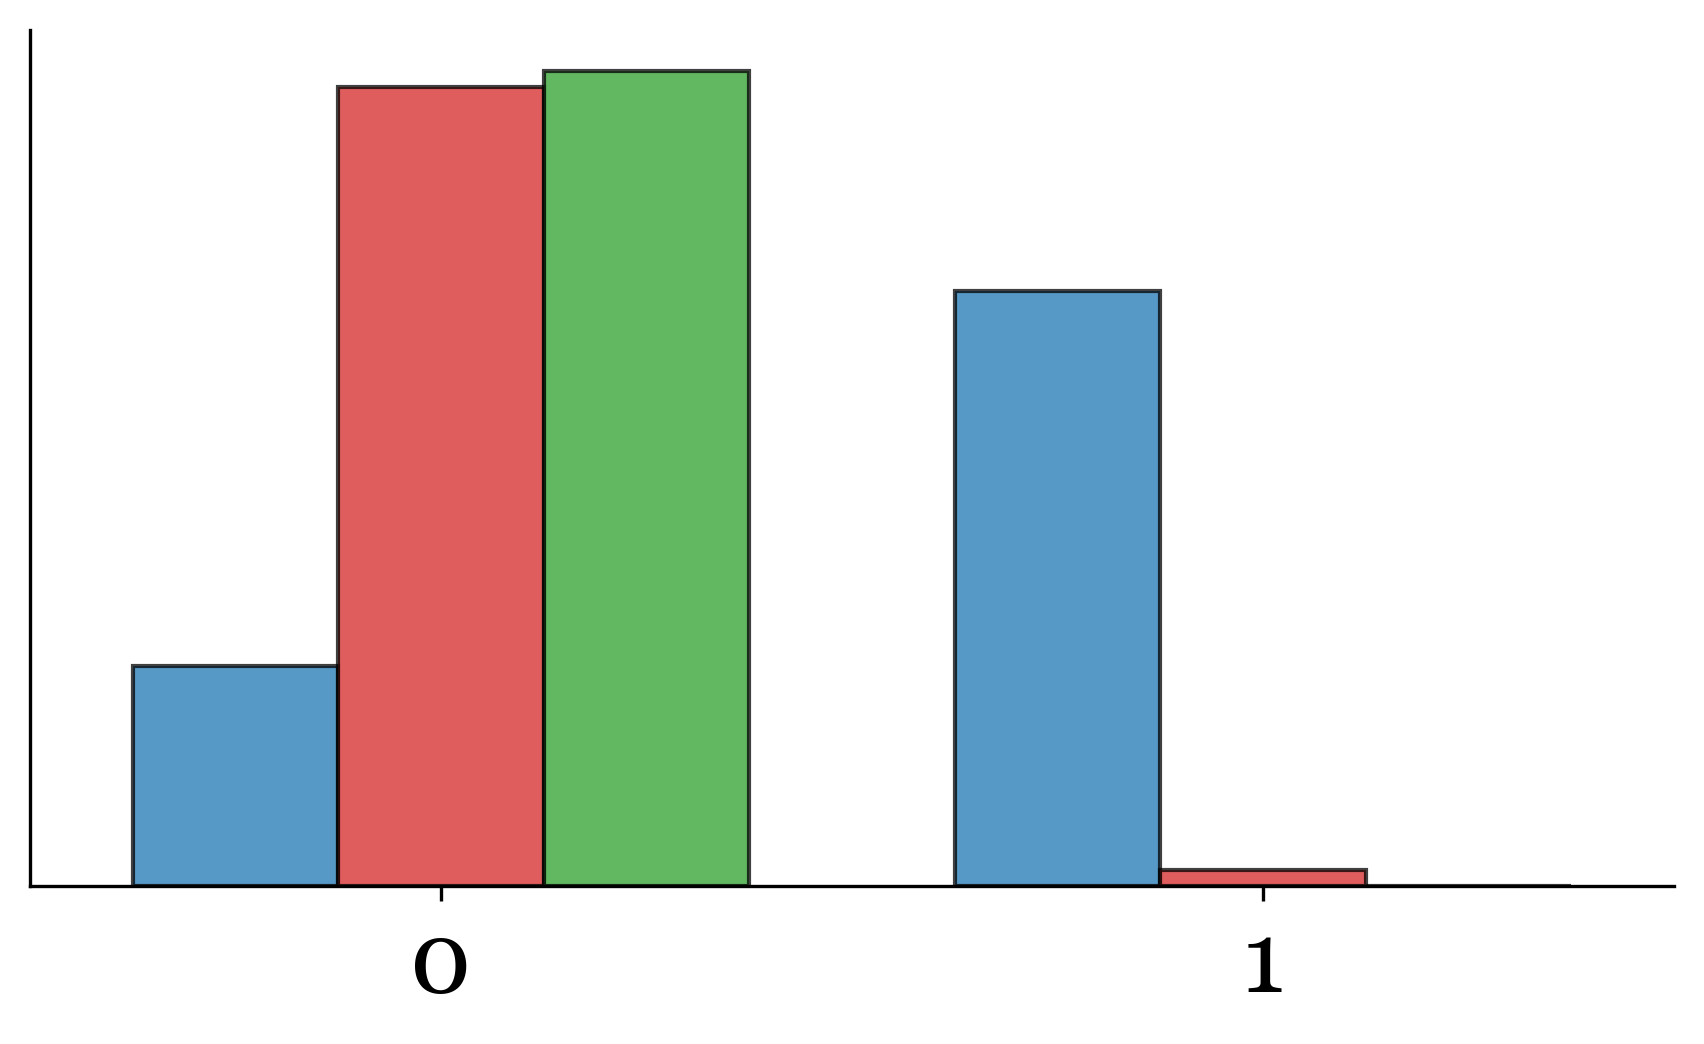

In [20]:
# --------------------------------------------------------------------
# Publication-quality Plot: L0 error distribution (grouped bar plot)
# --------------------------------------------------------------------

plt.rcParams.update({
    "font.family": "Georgia",
    "font.size": 24,
})

# Convert arrays
L0_std  = np.asarray(L0_std_runs)
L0_var  = np.asarray(L0_ones_runs)
L0_ones = np.asarray(L0_var_runs)

# Maximum L0 across all methods
k_max = int(max(L0_std.max(), L0_var.max(), L0_ones.max()))
k_vals = np.arange(0, k_max + 1, dtype=int)

# Count occurrences of each L0 error value
counts_std  = np.bincount(L0_std,  minlength=k_max + 1)
counts_var  = np.bincount(L0_var,  minlength=k_max + 1)
counts_ones = np.bincount(L0_ones, minlength=k_max + 1)

# Colors used in earlier figures
colors = ["#1f77b4", "#d62728", "#2ca02c"]  # blue, red, green
width  = 0.25

fig, ax = plt.subplots(figsize=(6.2, 4.0), dpi=300)

# Grouped bars
ax.bar(k_vals - width,
       counts_std,
       width=width,
       color=colors[0],
       alpha=0.75,
       edgecolor="black")

ax.bar(k_vals,
       counts_var,
       width=width,
       color=colors[1],
       alpha=0.75,
       edgecolor="black")

ax.bar(k_vals + width,
       counts_ones,
       width=width,
       color=colors[2],
       alpha=0.75,
       edgecolor="black")

# Axis labels
# ax.set_xlabel(r"$L_0$ support mismatch")
# ax.set_ylabel("Frequency")
ax.set_xticks(k_vals)
ax.set_yticks([])
ax.set_xlim(-0.5, k_max + 0.5)

# No legend (you will add it externally)
# ax.legend(...)

# Aesthetics
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle=":", linewidth=0.6, alpha=0.6)

plt.tight_layout()
plt.show()
